This notebook just takes the output csv and .npy files generated during training and visualizes the results. It does not run inference

In [4]:
# In your first cell, turn on the ipympl interactive backend:
%matplotlib widget

/tmp/ipykernel_111229/1804132403.py:127: UserWarning: The figure layout has changed to tight
  fig.tight_layout()    # <— call before show()


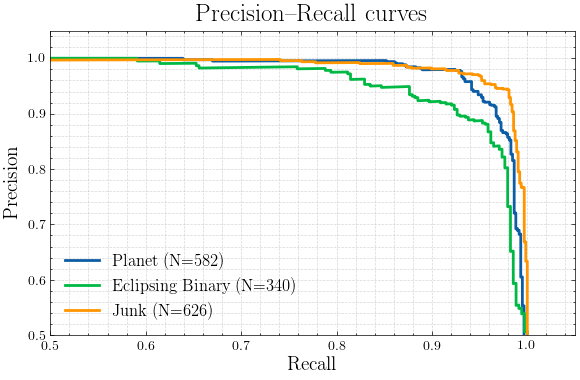

[[886  36]
 [ 16 610]]
                  precision    recall  f1-score   support

          Planet       0.91      0.97      0.94       582
Eclipsing Binary       0.98      0.81      0.89       340
            Junk       0.94      0.98      0.96       626

        accuracy                           0.94      1548
       macro avg       0.95      0.92      0.93      1548
    weighted avg       0.94      0.94      0.94      1548



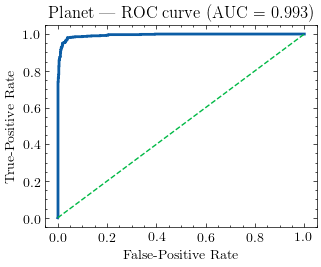

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)

import scienceplots
plt.style.use('science')

#0 Load the data
training_run_folder="/pdo/users/pablomer/mnt/tess/models/vetting/20250502/cshallue/AstroCNNModelVetting_cshallue_20250502_000812"

# Load raw predictions
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy") # Shape: (1548, 4)
test_pred= np.load(f"{training_run_folder}/evaluation/test_pred.npy")
test_astroids = np.load(f"{training_run_folder}/evaluation/test_astro_ids.npy")

# 1 Remove the Not SUre (third Column)
test_labels = np.delete(test_labels, 2, axis=1)
test_pred = np.delete(test_pred, 2, axis=1)
label_names=["Planet","Eclipsing Binary","Junk"]

classes_to_include_in_PR_curve = ["Planet","Eclipsing Binary","Junk"]
include_numbers = True

# ------------------------------------------------------------------
# 2. Pick which class you want to inspect
#    (0 = Planet, 1 = EB, 2 = Not Sure, 3 = Junk)
# ------------------------------------------------------------------
CLASS = 0
y_true = test_labels[:, CLASS]
y_score = test_pred[:, CLASS]

# ------------------------------------------------------------------
# 3. Compute PR data
# ------------------------------------------------------------------
# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(classes_to_include_in_PR_curve)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ------------------------------------------------------------------
# 4. Interactive PR curve — click to display (P, R, t)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)


ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)


annot = ax.annotate(
    "",
    xy=(0, 0),
    xytext=(-40, -20),        # shift the box 60pt left, 40pt down
    textcoords="offset points",
    ha="right",               # right‐align text inside the box
    va="top",                 # top‐align text inside the box
    bbox=dict(
        boxstyle="round,pad=0.5",
        fc="w",
        alpha=0.9,
        clip_on=False         # ensure nothing is clipped
    ),
    arrowprops=dict(arrowstyle="->")
)


annot.set_visible(False)



def _update_annot(ind):
    idx = ind["ind"][0]
    annot.xy = (recall[idx], precision[idx])
    annot.set_text(
        f"Precision = {precision[idx]:.3f}\n"
        f"Recall    = {recall[idx]:.3f}\n"
        f"Threshold = {thresholds[idx]:.3f}"
    )
    annot.get_bbox_patch().set_alpha(0.9)


def _onclick(event):
    vis = annot.get_visible()
    if event.inaxes == ax:
        cont, ind = line.contains(event)
        if cont:
            _update_annot(ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
        elif vis:
            annot.set_visible(False)
            fig.canvas.draw_idle()
    # fig.subplots_adjust(right=0.75)


ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
fig.canvas.mpl_connect("button_press_event", _onclick)
fig.tight_layout()    # <— call before show()
plt.show()

# ------------------------------------------------------------------
# 5. More diagnostics (uncomment what you need)
# ------------------------------------------------------------------
# Confusion matrix at the default threshold 0.5
cm = confusion_matrix(y_true, (y_score >= 0.5).astype(int))
print(cm)

# Full classification report for all four classes
print(classification_report(test_labels.argmax(1), test_pred.argmax(1), target_names=label_names))

# ROC curve & AUC for this class
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr, lw=2)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False-Positive Rate")
plt.ylabel("True-Positive Rate")
plt.title(f"{label_names[CLASS]} — ROC curve  (AUC = {auc:.3f})")
plt.show()

# Per-class PR-AUC summary
# print({name: average_precision_score(test_labels[:, i], test_pred[:, i]) for i, name in enumerate(label_names)})


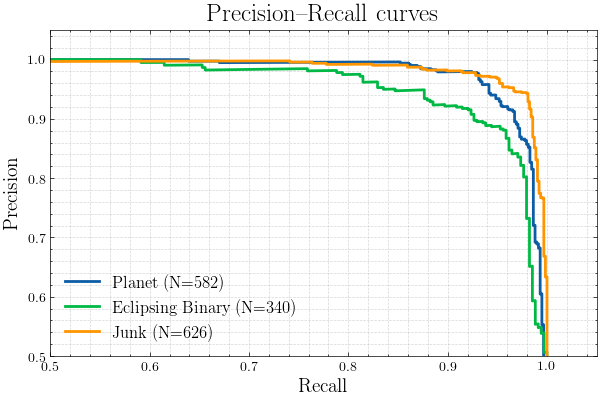

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
import scienceplots

plt.style.use('science')
# If you want widget‐based clicks in a Jupyter environment, uncomment:
# %matplotlib widget

# ─── 0) load & preprocess ────────────────────────────────────────────────
training_run_folder = "/pdo/users/pablomer/mnt/tess/models/vetting/20250502/" \
                      "cshallue/AstroCNNModelVetting_cshallue_20250502_000812"
test_labels = np.load(f"{training_run_folder}/evaluation/test_label.npy")  # (1548,4)
test_pred   = np.load(f"{training_run_folder}/evaluation/test_pred.npy")

# drop the “Not Sure” column
test_labels = np.delete(test_labels, 2, axis=1)
test_pred   = np.delete(test_pred,   2, axis=1)

label_names = ["Planet", "Eclipsing Binary", "Junk"]
counts = test_labels.sum(axis=0).astype(int)

# ─── 1) compute PR for each class ────────────────────────────────────────
pr_data = []
for i in range(len(label_names)):
    y_true  = test_labels[:, i]
    y_score = test_pred[:,   i]
    p, r, t  = precision_recall_curve(y_true, y_score)
    ap       = average_precision_score(y_true, y_score)
    pr_data.append({
        "precision": p,
        "recall":    r,
        "thresholds":t,
        "ap":        ap
    })

# ─── 2) plot all three curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

lines = []
for i, name in enumerate(label_names):
    data = pr_data[i]
    lbl  = f"{name} (N={counts[i]})"
    ln, = ax.plot(data["recall"][:-1],
                  data["precision"][:-1],
                  lw=2, label=lbl)
    lines.append(ln)

ax.set_xlabel("Recall",    fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision–Recall curves", fontsize=18)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.5, 1.05)

# ─── 3) add interactive annotation ───────────────────────────────────────
annot = ax.annotate(
    "",
    xy=(0,0), xytext=(-40,-20),
    textcoords="offset points",
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="w", alpha=0.9, clip_on=False),
    arrowprops=dict(arrowstyle="->")
)
annot.set_visible(False)

def update_annot(class_idx, ind):
    idx = ind["ind"][0]
    d   = pr_data[class_idx]
    annot.xy = (d["recall"][idx], d["precision"][idx])
    annot.set_text(
        f"{label_names[class_idx]}\n"
        f"Precision = {d['precision'][idx]:.3f}\n"
        f"Recall = {d['recall'][idx]:.3f}\n"
        f"Threshold = {d['thresholds'][idx]:.3f}"
    )

def onclick(event):
    if event.inaxes != ax:
        return
    for i, ln in enumerate(lines):
        hit, ind = ln.contains(event)
        if hit:
            update_annot(i, ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
            return
    # click elsewhere hides the box
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", onclick)

# ─── 4) legend & show ───────────────────────────────────────────────────
ax.legend(loc="lower left", fontsize=12, framealpha=0.8)
plt.show()

# ─── 5) extra diagnostics (optional) ────────────────────────────────────
# You can still compute confusion matrices, ROC, etc., exactly as before.
